In [1]:
import pandas as pd
import seaborn as sns
import anndata as ad
import matplotlib.pyplot as plt

# Purpose

SHow that simulated GO terms with higher brain MGC scores are more learnable from brain composition-induced co-expression

In [13]:

def load_results(path):
	"""Load the performance of simulated GO terms
	"""
	df = pd.read_csv(path, index_col=0)
	df['exp_type'] = df.loc[:,'organism_part'].str.split("_").str[0]
	df =  df[df.loc[:,'exp_type']=='exp']
	df['Q'] = df.loc[:,'index'].str.split("_").str[-1]
	return df

def aggr(df):
	agg = pd.DataFrame(df.groupby(['index'])['auc'].agg(['mean','std'])).reset_index()
	agg['Q'] = agg.loc[:,'index'].str.split("_").str[-1]
	return agg

def load_agg(path):
	df = load_results(path)
	df_agg = aggr(df)
	return df_agg

path = "/space/grp/aadrian/Pseudobulk_Function_Pipeline_HighRes/bin/EGADSimulatedGOTerms/data/sim_go_apr23_brain/master_melted_df.csv.gz" # old
agg = load_agg(path)
agg

,index,mean,std,Q
0,SIMGO_100_Q1,0.603102,0.020387,Q1
1,SIMGO_100_Q2,0.542924,0.038388,Q2
2,SIMGO_100_Q3,0.767005,0.055236,Q3
3,SIMGO_101_Q1,0.623064,0.020143,Q1
4,SIMGO_101_Q2,0.516774,0.049411,Q2
...,...,...,...,...
2992,SIMGO_99_Q2,0.440763,0.056188,Q2
2993,SIMGO_99_Q3,0.764820,0.056393,Q3
2994,SIMGO_9_Q1,0.648185,0.021963,Q1
2995,SIMGO_9_Q2,0.510479,0.052633,Q2


In [9]:
df.head()

,Unnamed: 0,index,bootstrap,auc
0,0,SIMGO_1_Q1,38,0.619496
1,1,SIMGO_2_Q1,38,0.614270
2,2,SIMGO_3_Q1,38,0.578866
3,3,SIMGO_4_Q1,38,0.676923
4,4,SIMGO_5_Q1,38,0.623925


In [5]:
agg

,index,mean,std,Q
0,GO:0000045,0.552830,0.021763,GO:0000045
1,GO:0000070,0.486835,0.029267,GO:0000070
2,GO:0000077,0.496665,0.032705,GO:0000077
3,GO:0000079,0.474125,0.031974,GO:0000079
4,GO:0000082,0.492510,0.028403,GO:0000082
...,...,...,...,...
1391,GO:2001237,0.481535,0.029103,GO:2001237
1392,GO:2001238,0.396610,0.038970,GO:2001238
1393,GO:2001240,0.498968,0.028955,GO:2001240
1394,GO:2001243,0.485114,0.042630,GO:2001243


### Plot

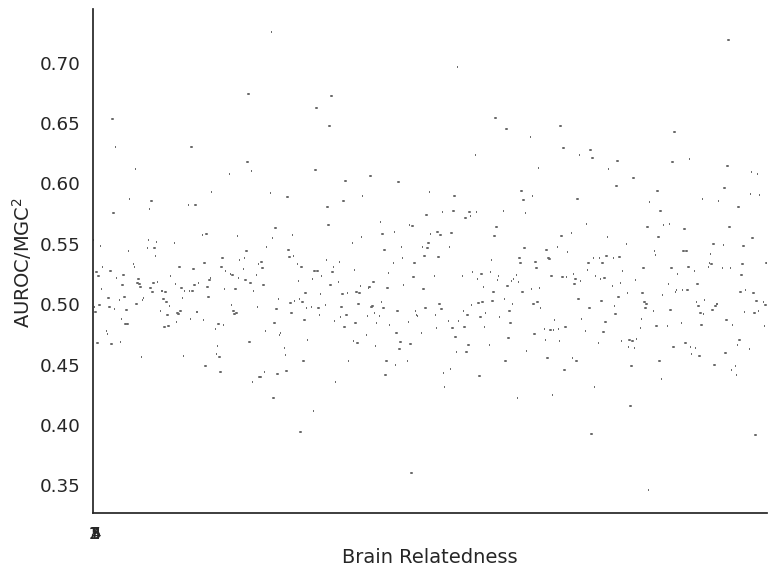

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot(df):
    # Set Seaborn style
    sns.set(style="white", font_scale=1.2)
    
    # Figure size
    plt.figure(figsize=(8, 6))
    
    # Color palette
    set2_colors = sns.color_palette("Set2")
    
    # Boxplot
    sns.boxplot(
        data=df, 
        x="Q", 
        y="mean", 
        color=set2_colors[1],
        fliersize=0,    # optional: hide outliers
        linewidth=1.2   # thicker box lines for publication
    )
    
    # X-axis labels
    plt.xticks([0,1,2], ['1', '2', '3', '4', '5'], fontsize=12)
    plt.xlabel("Brain Relatedness", fontsize=14)
    
    # Y-axis label with inline LaTeX (smaller and inline)
    plt.ylabel(r"$\mathrm{AUROC}/\mathrm{MGC}^2$", fontsize=14)
    
    # Remove top and right spines
    sns.despine()
    
    # Tight layout
    plt.tight_layout()
    
    # Save figures
    plt.savefig("figs/brain_performance_by_brain_mgc.png", dpi=300, transparent=True)
    plt.savefig("figs/brain_performance_by_brain_mgc.svg", dpi=300, transparent=True)
    
    plt.show()

# Call the function
plot(agg)

### Stat analysis

Mixed effects model

In [4]:
import statsmodels.formula.api as smf
from scipy.stats import chi2

def model_real(df):
	df = load_results(path = path)
	df["Q"] = df["Q"].str[-1].astype(int)
	df["Qsqr"] = df["Q"]**2
	model = smf.mixedlm("auc ~ Q + Qsqr", data=df, groups=df["index"])
	result = model.fit()
	return result


df = load_results(path)
real_model = model_real(df)


ValueError: cannot convert float NaN to integer

In [ ]:
real_model.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: auc        
No. Observations: 49750   Method:             REML       
No. Groups:       995     Scale:              0.0005     
Min. group size:  50      Log-Likelihood:     116984.8079
Max. group size:  50      Converged:          Yes        
Mean group size:  50.0                                   
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept      0.500    0.004 133.349 0.000  0.493  0.508
Q             -0.029    0.003 -10.269 0.000 -0.035 -0.024
Qsqr           0.009    0.000  19.820 0.000  0.008  0.010
Group Var      0.001    0.001                            
=========================================================

"""